<a href="https://colab.research.google.com/github/AvaneeshN/MAHE-Mobility/blob/main/notebooks/bev_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1 — Fix nuscenes version first, before anything else
!pip install -q nuscenes-devkit==1.1.9 --only-binary=:all:
print("Done — now click Runtime → Restart Session")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 312.6/312.6 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 68.8 MB/s eta 0:00:00
Done — now click Runtime → Restart Session


In [1]:
# Cell 2 — Mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Cell 3 — Extract dataset
import os, tarfile
if not os.path.exists('/content/nuscenes/v1.0-mini'):
    with tarfile.open('/content/drive/MyDrive/DataSet/v1.0-mini.tgz', 'r:gz') as tar:
        tar.extractall('/content/nuscenes')
    print("Extracted ✓")
else:
    print("Already extracted ✓")

/tmp/ipykernel_31861/1956346712.py:5: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall('/content/nuscenes')


Extracted ✓


In [3]:
# Cell 4 — Clone repo + install remaining packages
os.chdir('/content')
!rm -rf MAHE-Mobility
!git clone https://github.com/AvaneeshN/MAHE-Mobility.git
os.chdir('/content/MAHE-Mobility')
!pip install -q ultralytics timm pyquaternion --only-binary=:all:

Cloning into 'MAHE-Mobility'...
remote: Enumerating objects: 169, done.
remote: Counting objects: 100% (169/169), done.
remote: Compressing objects: 100% (107/107), done.
remote: Total 169 (delta 75), reused 110 (delta 51), pack-reused 0 (from 0)
Receiving objects: 100% (169/169), 560.70 KiB | 11.44 MiB/s, done.
Resolving deltas: 100% (75/75), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.8 MB/s eta 0:00:00


In [4]:
# Cell 5 — Test dataset loads
import sys
sys.path.insert(0, "/content/MAHE-Mobility")

from src.data.nuscenes_loader import NuScenesLoader
loader = NuScenesLoader(dataroot="/content/nuscenes", version="v1.0-mini")
print(f"Total samples: {len(loader)}")
sample = loader.get_sample(0)
print(f"Image shape: {sample['image'].shape}")
print("✓ Dataset loaded successfully")

Loading nuScenes v1.0-mini from /content/nuscenes...
Loaded 404 samples.
Total samples: 404
Image shape: (900, 1600, 3)
✓ Dataset loaded successfully


In [5]:
# Cell 6 — Write config
import yaml

cfg = {
    "camera": {
        "fx": 1266.417203,
        "fy": 1266.417203,
        "cx": 816.2670196,
        "cy": 491.5075969,
        "height": 1.51
    },
    "grid": {
        "size": 40.0,
        "resolution": 0.1,
        "height_thresh": 0.5
    },
    "models": {
        "yolo": "yolov8n.pt",
        "depth": "MiDaS_small"
    },
    "nuscenes": {
        "dataroot": "/content/nuscenes",
        "version": "v1.0-mini"
    },
    "depth": {
        "scale_factor": 20.0,
        "min_depth": 1.0,
        "max_depth": 50.0
    }
}

with open("configs/configs.yaml", "w") as f:
    yaml.dump(cfg, f)

print("Config written ✓")

Config written ✓


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Loading nuScenes v1.0-mini from /content/nuscenes...
Loaded 404 samples.


/usr/local/lib/python3.12/dist-packages/torch/hub.py:247: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  _check_repo_is_trusted(


Downloading: "https://github.com/intel-isl/MiDaS/zipball/master" to /root/.cache/torch/hub/master.zip
Loading weights:  None


/usr/local/lib/python3.12/dist-packages/torch/hub.py:247: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  _check_repo_is_trusted(


Downloading: "https://github.com/rwightman/gen-efficientnet-pytorch/zipball/master" to /root/.cache/torch/hub/master.zip
Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-weights/tf_efficientnet_lite3-b733e338.pth" to /root/.cache/torch/hub/checkpoints/tf_efficientnet_lite3-b733e338.pth
Downloading: "https://github.com/isl-org/MiDaS/releases/download/v2_1/midas_v21_small_256.pt" to /root/.cache/torch/hub/checkpoints/midas_v21_small_256.pt


100%|██████████| 81.8M/81.8M [00:00<00:00, 224MB/s]


Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master



--- Sample 1 ---

0: 384x640 1 person, 4 cars, 1 truck, 208.0ms
Speed: 5.5ms preprocess, 208.0ms inference, 39.1ms postprocess per image at shape (1, 3, 384, 640)
Detections: 6
Grid occupied cells: 0
Saved → outputs/bev_sample_0.png


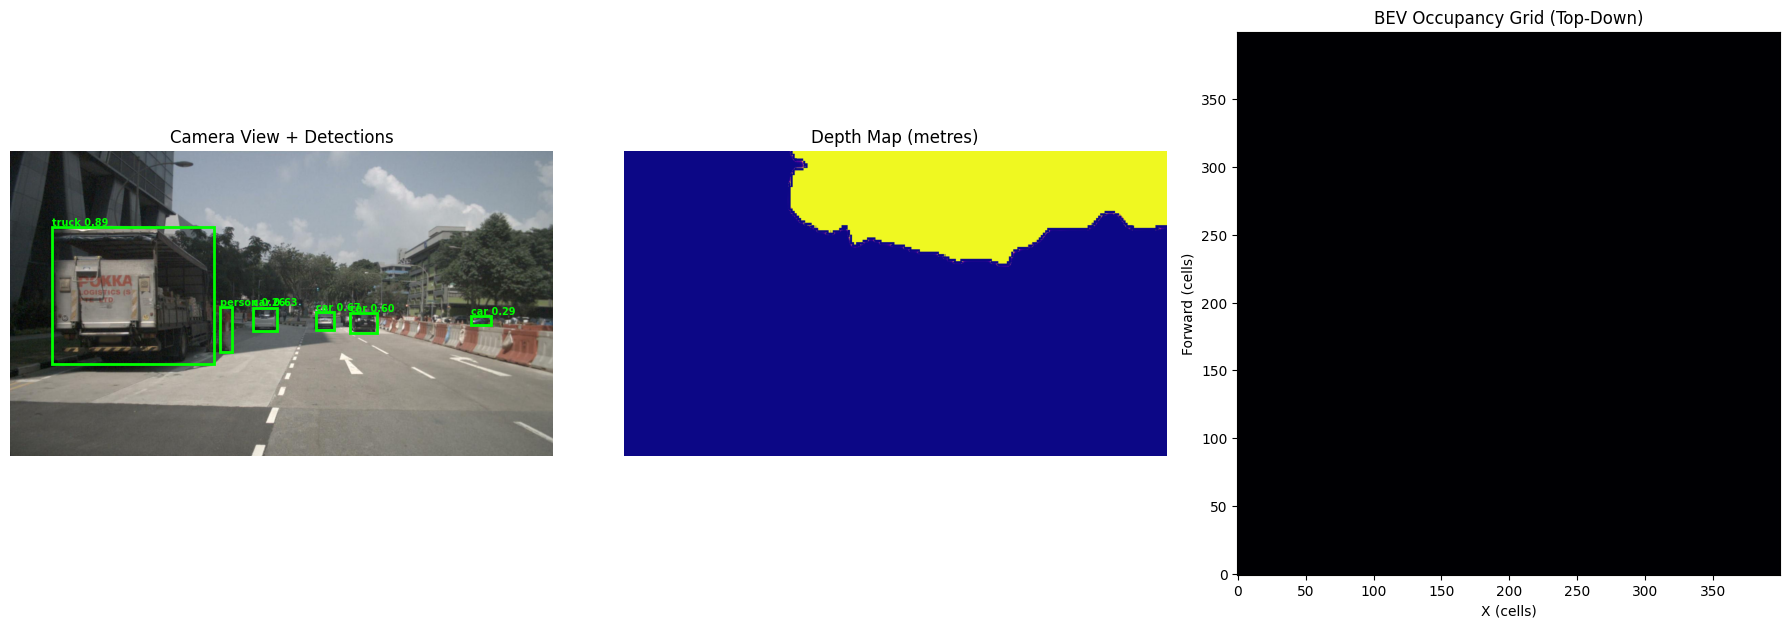


--- Sample 2 ---

0: 384x640 1 person, 5 cars, 1 bus, 1 truck, 139.2ms
Speed: 4.0ms preprocess, 139.2ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)
Detections: 8
Grid occupied cells: 0
Saved → outputs/bev_sample_1.png


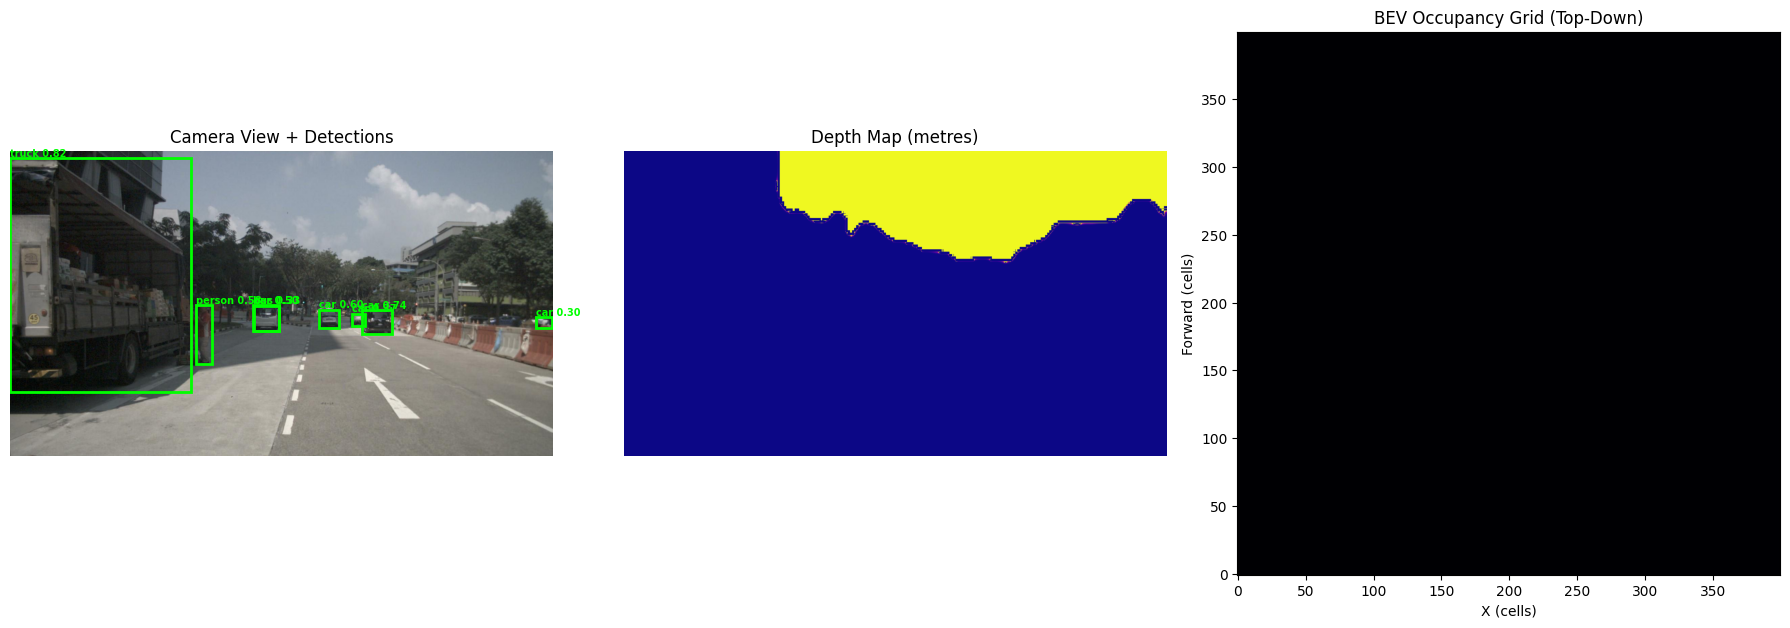


--- Sample 3 ---

0: 384x640 1 person, 7 cars, 1 truck, 127.6ms
Speed: 3.7ms preprocess, 127.6ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)
Detections: 9
Grid occupied cells: 0
Saved → outputs/bev_sample_2.png


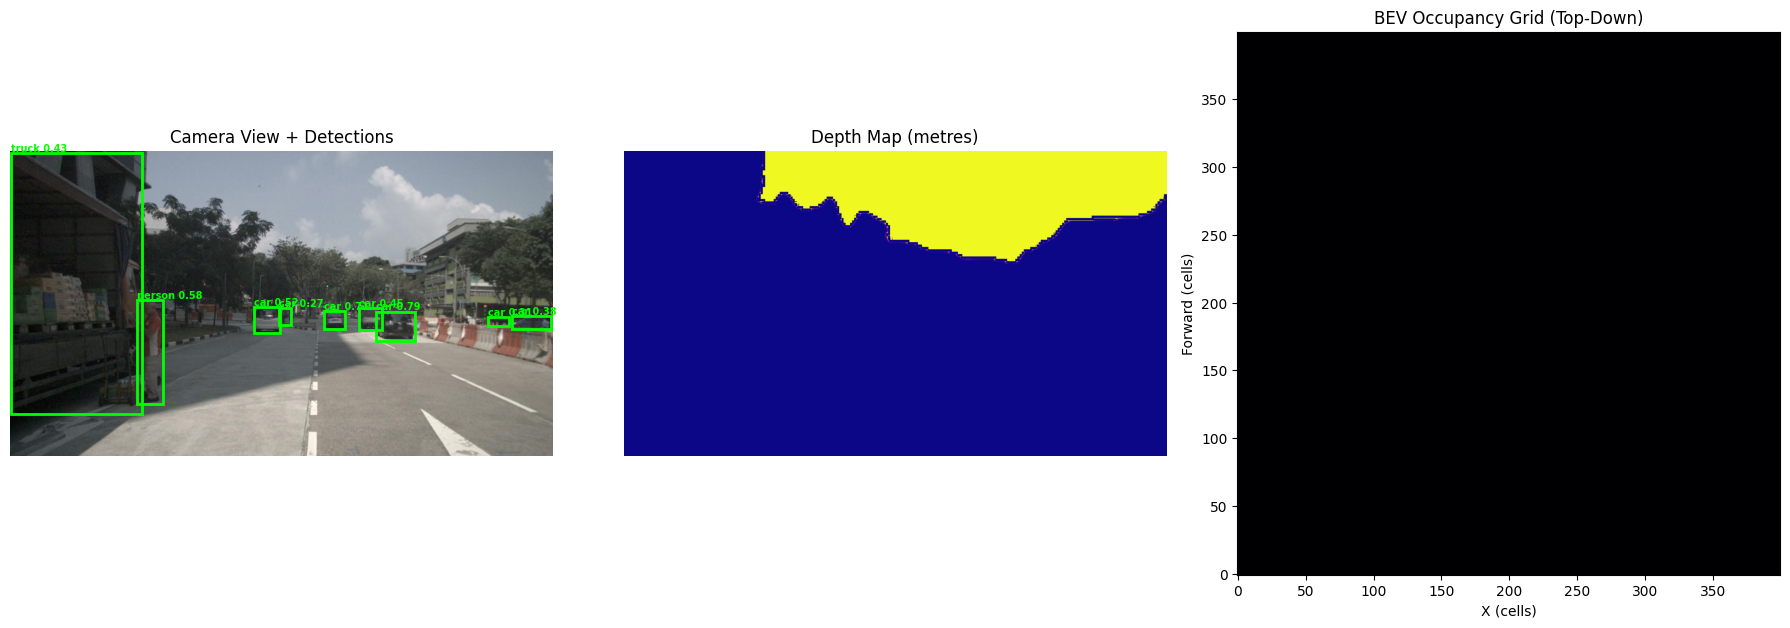


--- Sample 4 ---

0: 384x640 4 cars, 1 bus, 1 truck, 142.0ms
Speed: 4.2ms preprocess, 142.0ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)
Detections: 6
Grid occupied cells: 0
Saved → outputs/bev_sample_3.png


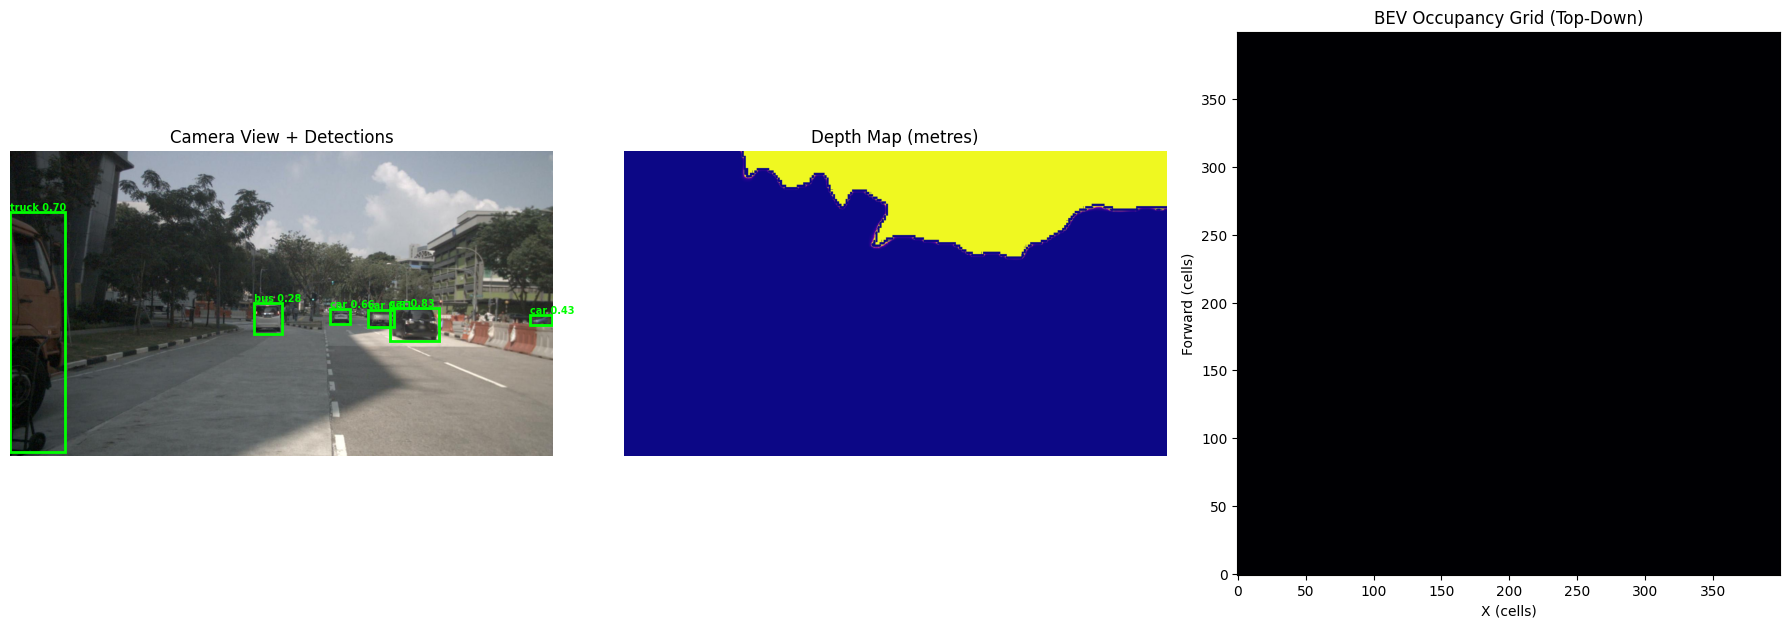


--- Sample 5 ---

0: 384x640 3 cars, 195.7ms
Speed: 4.2ms preprocess, 195.7ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)
Detections: 3
Grid occupied cells: 0
Saved → outputs/bev_sample_4.png


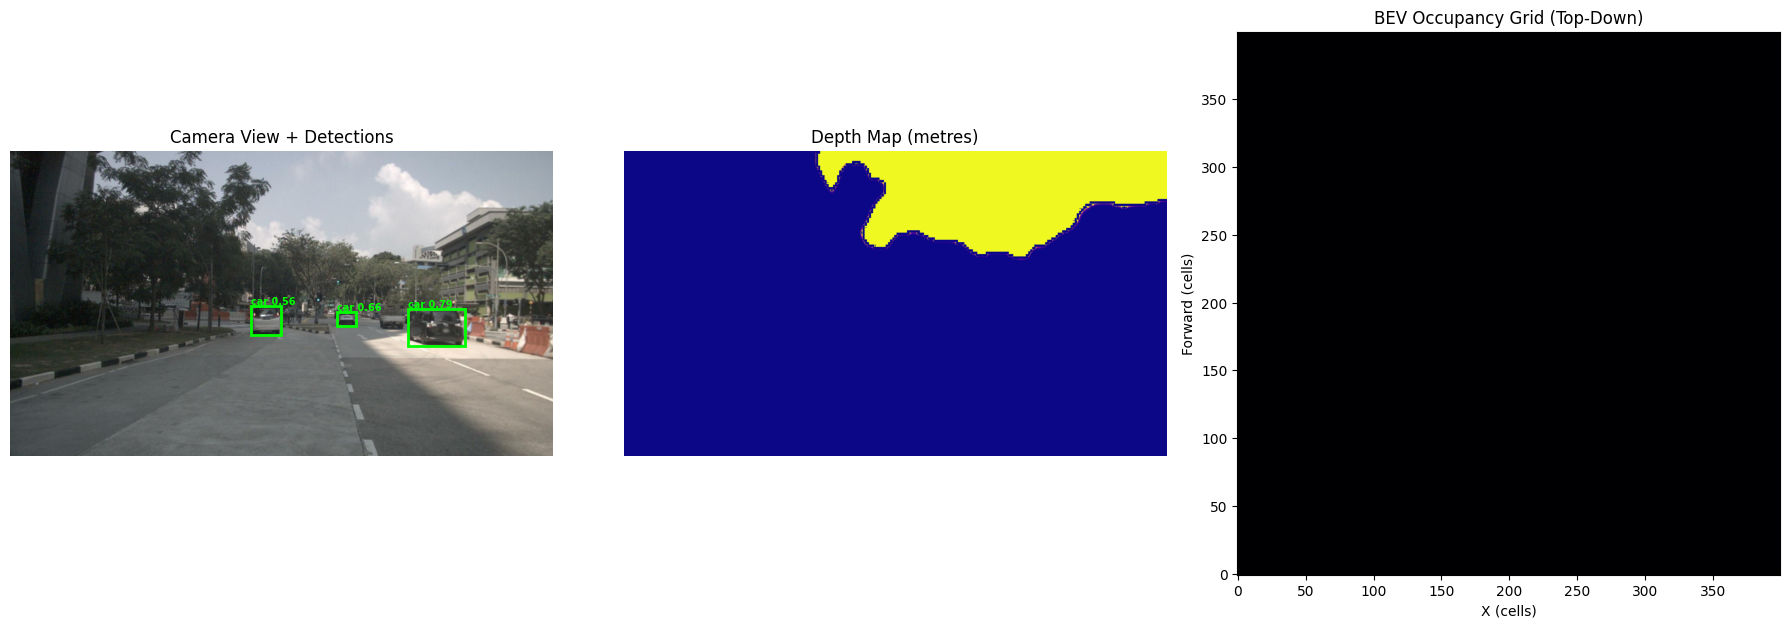

In [6]:
# Cell 7 — Run full pipeline
from src.pipeline import main
main()

Loading nuScenes v1.0-mini from /content/nuscenes...
Loaded 404 samples.


Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


Loading weights:  None


Using cache found in /root/.cache/torch/hub/rwightman_gen-efficientnet-pytorch_master
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master



0: 384x640 1 person, 4 cars, 1 truck, 149.5ms
Speed: 3.3ms preprocess, 149.5ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)
Sample 1: 4436 valid points
  X range: -10.0 to 19.9
  Z range: 1.0 to 39.9
  Occupied cells: 1234


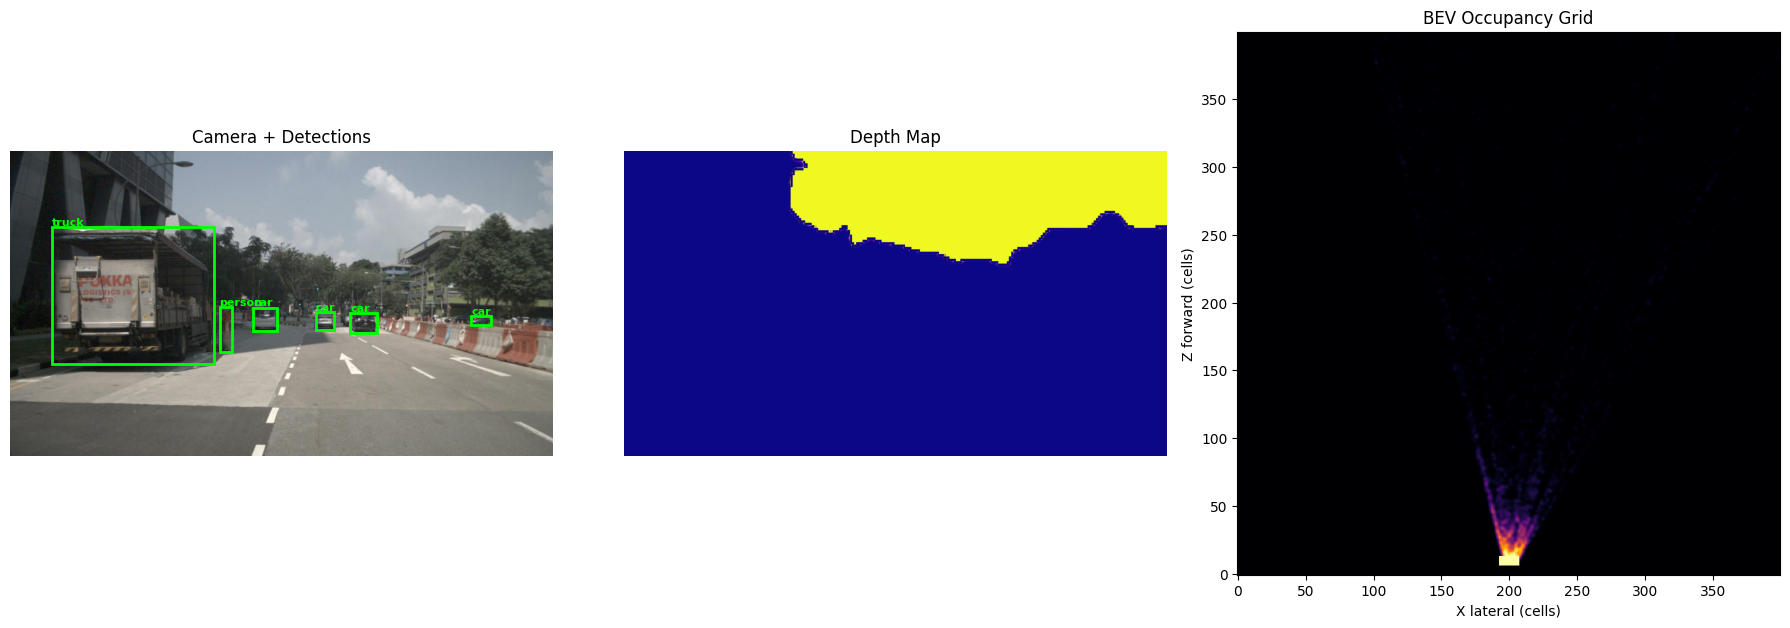

Saved → outputs/bev_fixed_1.png


0: 384x640 1 person, 5 cars, 1 bus, 1 truck, 138.3ms
Speed: 4.6ms preprocess, 138.3ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)
Sample 2: 5817 valid points
  X range: -11.4 to 20.0
  Z range: 1.0 to 39.9
  Occupied cells: 1645


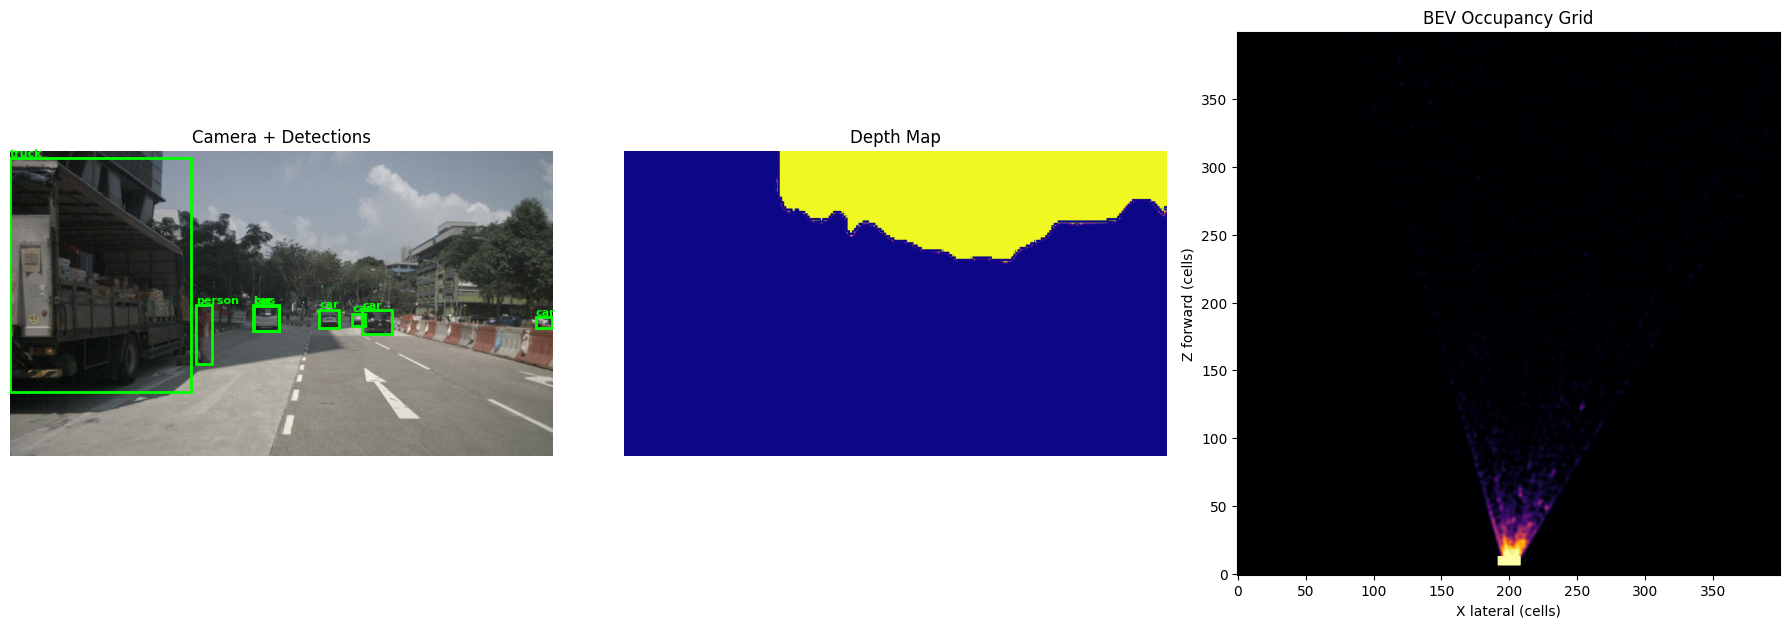

Saved → outputs/bev_fixed_2.png


0: 384x640 1 person, 7 cars, 1 truck, 146.0ms
Speed: 5.7ms preprocess, 146.0ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)
Sample 3: 5601 valid points
  X range: -11.7 to 20.0
  Z range: 1.0 to 39.9
  Occupied cells: 1504


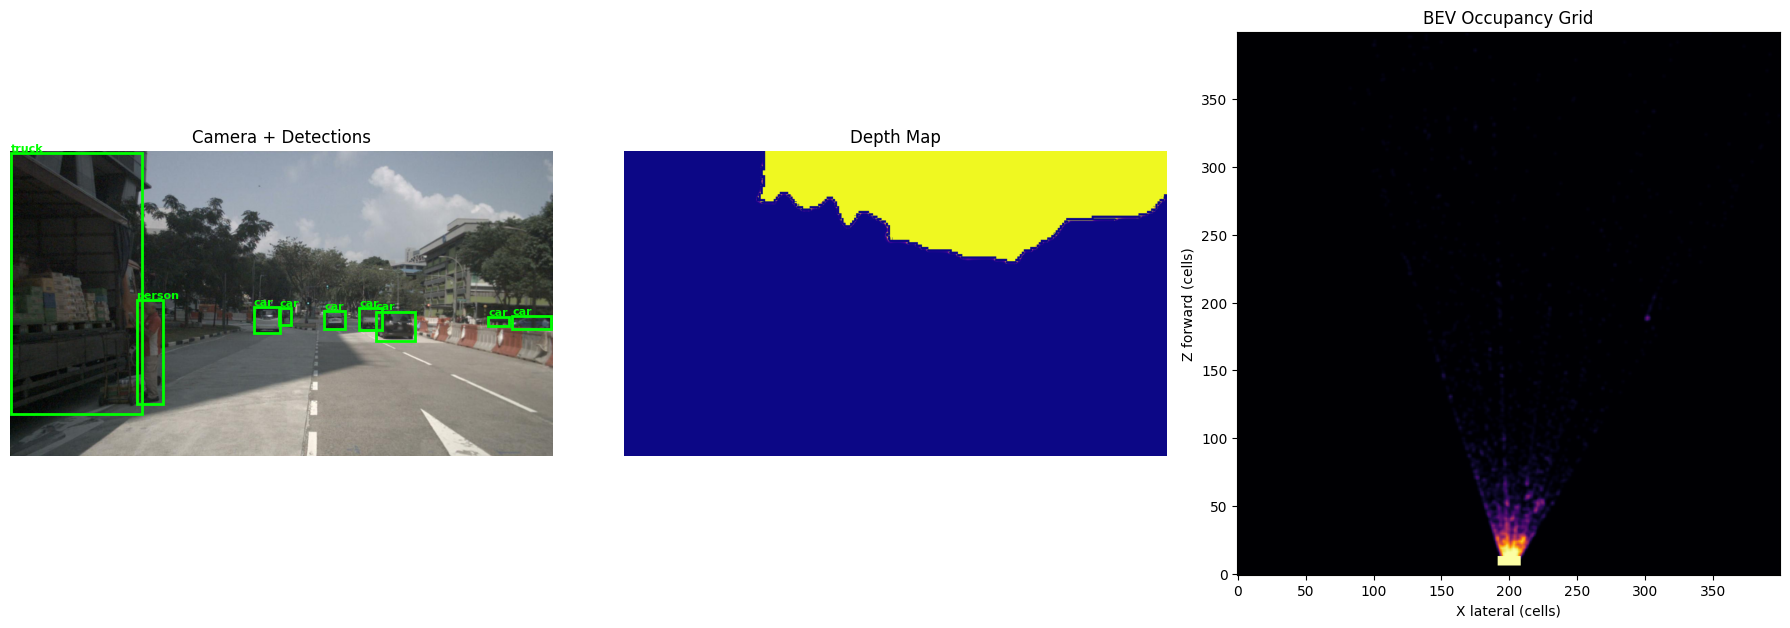

Saved → outputs/bev_fixed_3.png



In [7]:
# Cell 8 — Fix occupancy grid coordinate issue
import sys
sys.path.insert(0, "/content/MAHE-Mobility")

import cv2
import numpy as np
import matplotlib.pyplot as plt
import yaml

from src.data.nuscenes_loader import NuScenesLoader
from src.depth.estimator import DepthEstimator
from src.geometry.camera import Camera
from src.perception.detector import ObjectDetector
from src.mapping.point_cloud import depth_to_point_cloud
from src.mapping.occupancy_grid import OccupancyGrid

with open("configs/configs.yaml", "r") as f:
    cfg = yaml.safe_load(f)

loader = NuScenesLoader(dataroot="/content/nuscenes", version="v1.0-mini")
depth_estimator = DepthEstimator(model_type="MiDaS_small", scale_factor=20.0)
detector = ObjectDetector()

for i in range(3):
    sample = loader.get_sample(i)
    image = sample["image"]
    K = sample["intrinsic"]

    # Use identity extrinsics — stay in camera frame, simpler
    camera = Camera(fx=K[0,0], fy=K[1,1], cx=K[0,2], cy=K[1,2])

    depth = depth_estimator.predict(image)
    detections = detector.detect(image)

    # Get point cloud in camera frame directly
    points = depth_to_point_cloud(depth, camera)

    # In camera frame: X=right, Y=down, Z=forward
    # Filter: keep points where Z (forward) is 1-40m
    # and Y (height) is reasonable (not sky, not ground too far)
    mask = (points[:, 2] > 1.0) & (points[:, 2] < 40.0) & \
           (np.abs(points[:, 0]) < 20.0)
    points = points[mask]

    print(f"Sample {i+1}: {len(points)} valid points")
    print(f"  X range: {points[:,0].min():.1f} to {points[:,0].max():.1f}")
    print(f"  Z range: {points[:,2].min():.1f} to {points[:,2].max():.1f}")

    # Build grid using X (lateral) and Z (forward) directly
    grid = OccupancyGrid(size=40.0, resolution=0.1)
    grid.fill(points)
    grid.smooth()

    # Also mark detected objects
    for det in detections:
        x1, y1, x2, y2, label, conf = det
        if label not in ["car","truck","bus","motorcycle","person"]:
            continue
        u = int((x1+x2)/2)
        v = int(y2)
        u = np.clip(u, 0, depth.shape[1]-1)
        v = np.clip(v, 0, depth.shape[0]-1)
        Z = float(depth[v, u])
        if Z <= 0 or Z > 40:
            continue
        X = (u - K[0,2]) * Z / K[0,0]
        col, row = grid.world_to_grid(np.array([X]), np.array([Z]))
        col, row = int(col[0]), int(row[0])
        for dx in range(-3,4):
            for dy in range(-3,4):
                r, c = row+dy, col+dx
                if 0 <= r < grid.N and 0 <= c < grid.N:
                    grid.grid[r,c] = 1.0

    print(f"  Occupied cells: {(grid.grid > 0.1).sum()}")

    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    for det in detections:
        x1,y1,x2,y2,label,conf = det
        axes[0].add_patch(plt.Rectangle((x1,y1),x2-x1,y2-y1,
                          fill=False,edgecolor='lime',linewidth=2))
        axes[0].text(x1,y1-5,f"{label}",color='lime',fontsize=8,weight='bold')
    axes[0].set_title("Camera + Detections")
    axes[0].axis("off")

    axes[1].imshow(depth, cmap='plasma')
    axes[1].set_title("Depth Map")
    axes[1].axis("off")

    axes[2].imshow(grid.grid, cmap='inferno', origin='lower')
    axes[2].set_title("BEV Occupancy Grid")
    axes[2].set_xlabel("X lateral (cells)")
    axes[2].set_ylabel("Z forward (cells)")

    plt.tight_layout()
    path = f"outputs/bev_fixed_{i+1}.png"
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {path}\n")